In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Saved from Chrome/ecommerce_sales_data (2).csv')

In [5]:
df


,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


In [7]:
df.shape

(3500, 7)

In [8]:
df.describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


In [9]:
df.isnull().sum()

,0
Order Date,0
Product Name,0
Category,0
Region,0
Quantity,0
Sales,0
Profit,0


In [10]:
df.columns

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')

In [11]:
df['Sales'].sum()

np.int64(10667881)

In [12]:

df['Sales'].mean()

np.float64(3047.966)

In [16]:
product_sale=df.groupby('Product Name')['Sales'].sum()
product_sale.sort_values(ascending=False)

,Sales
Product Name,
Camera,1177381
Monitor,1160048
Printer,1094216
Mouse,1074398
Smartphone,1069681
Smartwatch,1049211
Keyboard,1024507
Tablet,1023928
Laptop,1005873


In [17]:
top_5_product=product_sale.sort_values(ascending=False).head(5)
top_5_product

,Sales
Product Name,
Camera,1177381
Monitor,1160048
Printer,1094216
Mouse,1074398
Smartphone,1069681


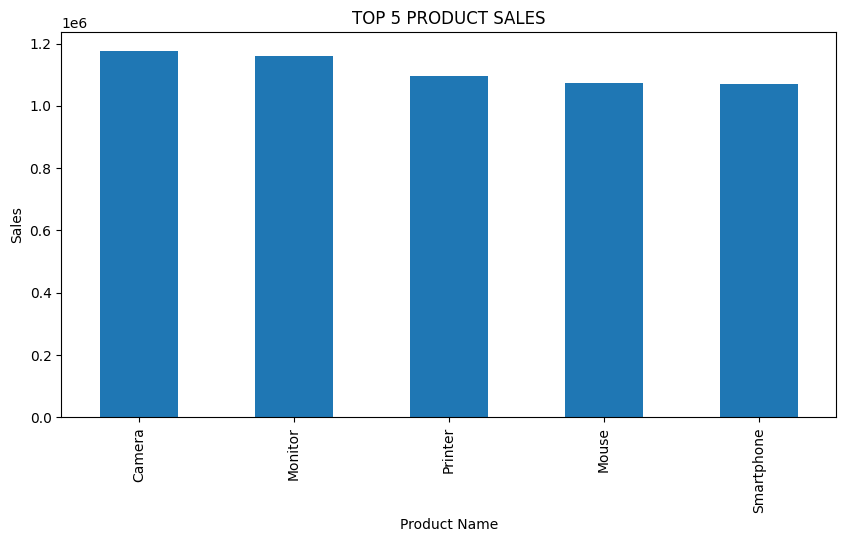

In [18]:
top_5_product.plot(kind='bar',figsize=(10,5))
plt.title('TOP 5 PRODUCT SALES')
plt.xlabel('Product Name')
plt.ylabel('Sales')
plt.show()

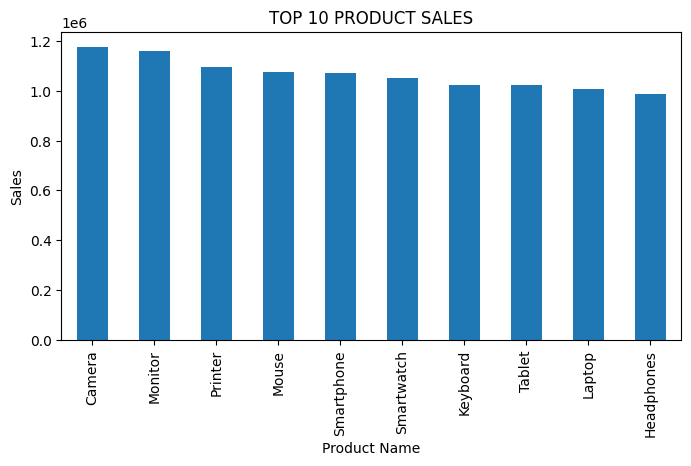

In [25]:
top_10_product=product_sale.sort_values(ascending=False).head(10)
top_10_product.plot(kind='bar',figsize=(8,4))
plt.title('TOP 10 PRODUCT SALES')
plt.xlabel('Product Name')
plt.ylabel('Sales')
plt.show()

In [26]:
df['Product Name'].value_counts()

,count
Product Name,
Monitor,364
Camera,363
Smartwatch,363
Printer,357
Keyboard,351
Tablet,350
Mouse,347
Headphones,339
Laptop,336


In [32]:
high_sales=df[df['Sales']>1000]
high_sales.head()


,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
6,2023-10-09,Headphones,Accessories,North,7,6167,1027.98
7,2022-01-14,Camera,Electronics,South,7,3059,873.50


In [36]:
high_sales=df[(df['Quantity']>5)&(df['Sales']>1000)]
high_sales.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
6,2023-10-09,Headphones,Accessories,North,7,6167,1027.98
7,2022-01-14,Camera,Electronics,South,7,3059,873.50
8,2022-04-02,Smartwatch,Electronics,East,9,5526,595.28
10,2023-12-04,Monitor,Accessories,South,6,7074,1357.68


In [41]:
pivot=df.pivot_table(index='Product Name',values='Sales',aggfunc='sum')
pivot

,Sales
Product Name,
Camera,1177381
Headphones,988638
Keyboard,1024507
Laptop,1005873
Monitor,1160048
Mouse,1074398
Printer,1094216
Smartphone,1069681
Smartwatch,1049211
